# Decode Position From Spikes

In this notebook, we will move from spatial firing maps to population decoding. The first step is to convert the mouse's 2D position on the X-maze into a 1D position along the track graph.


## 0. Setup

We will use the same DANDI session format as in the first tutorial, plus `track_linearization` to convert 2D `(x, y)` positions into a 1D coordinate along the maze.


In [34]:
%config InlineBackend.figure_format = 'retina'

import importlib
import json
import subprocess
import sys
import warnings
from pathlib import Path

PACKAGE_IMPORTS = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'plotly': 'plotly',
    'pillow': 'PIL',
    'seaborn': 'seaborn',
    'dandi': 'dandi',
    'pynwb': 'pynwb',
    'remfile': 'remfile',
    'h5py': 'h5py',
    'scipy': 'scipy',
    'scikit-learn': 'sklearn',
    'track-linearization': 'track_linearization',
}

# In Colab, only this notebook file is available locally, so companion files
# (the helper module and the track-graph spec) have to be fetched from GitHub.
if 'google.colab' in sys.modules:
    import urllib.request

    GITHUB_RAW_ROOT = 'https://raw.githubusercontent.com/anirudh073/camp2026/main/'
    COLAB_COMPANION_FILES = ['tutorial_utils.py', 'lovelace_track_graph_xmaze.json']

    for companion_filename in COLAB_COMPANION_FILES:
        if not Path(companion_filename).exists():
            urllib.request.urlretrieve(GITHUB_RAW_ROOT + companion_filename, companion_filename)
            print(f'Downloaded {companion_filename} from GitHub.')

failed = {}
for package, import_name in PACKAGE_IMPORTS.items():
    try:
        importlib.import_module(import_name)
    except Exception as exc:
        failed[package] = repr(exc)

print(f'Python executable: {sys.executable}')
print(f'Python version: {sys.version.split()[0]}')

if failed:
    print('Installing missing packages into this notebook kernel:', list(failed))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '--upgrade', *failed])
    print('Installed. If imports still fail, restart the runtime and rerun this cell.')
else:
    print('All required packages are available in this notebook kernel.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dandi.dandiapi import DandiAPIClient
import remfile
from h5py import File
from pynwb import NWBHDF5IO
from track_linearization import get_linearized_position, make_track_graph, plot_graph_as_1D, plot_track_graph

import tutorial_utils
importlib.reload(tutorial_utils)

from tutorial_utils import (
    apply_position_transition_prior,
    bin_linear_position,
    bin_spike_counts,
    build_graph_position_transition_matrix,
    build_segment_position_bin_table,
    centers_to_edges,
    COLORS,
    compute_occupancy_map,
    compute_poisson_log_likelihood,
    compute_rate_map,
    compute_segment_aware_tuning_curves_from_fine_data,
    get_unit_spike_times as fetch_unit_spike_times,
    hanning_smooth_1d,
    log_likelihood_to_posterior,
    make_time_bins,
    map_linear_positions_to_segment_stacked,
    map_spikes_to_position_frames,
    plot_posterior_linear_layout,
    plot_posterior_linear_layout_plotly,
    plot_posterior_segment_stacked_layout,
    plot_posterior_segment_stacked_layout_plotly,
    smooth_linear_rate_map,
    smooth_rate_map,
    subset_transition_matrix,
    unit_region_from_row,
)

warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(
    context='notebook',
    style='ticks',
    rc={
        'figure.dpi': 120,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
    },
)


Python executable: /Users/anirudh/Documents/camp2026/.venv/bin/python
Python version: 3.12.8
All required packages are available in this notebook kernel.


## 1. Stream one session

Use one session from Dandiset `001701`. Keep the file path explicit so it is easy to swap sessions later.


In [35]:
DANDISET_ID = "001701"
DANDISET_VERSION = "0.260120.0303"

# Match tutorial 1 so the spatial coding and decoding notebooks use the same session.
asset_path = "sub-Lovelace/sub-Lovelace_ses-Lovelace-DY07-g1_behavior+ecephys.nwb"
# asset_path = "sub-Lamarr/sub-Lamarr_ses-Lamarr-DY01-g0_behavior+ecephys.nwb"


In [36]:
client = DandiAPIClient()
dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
asset = dandiset.get_asset_by_path(asset_path)
stream_url = asset.get_content_url(follow_redirects=1, strip_query=True)

remote_file = File(remfile.File(stream_url), 'r')
io = NWBHDF5IO(file=remote_file, mode='r', load_namespaces=True)
nwb = io.read()

print('Streaming NWB file:')
print(asset.path)
print('\nSession description:', nwb.session_description)
print('Identifier:', nwb.identifier)


Streaming NWB file:
sub-Lovelace/sub-Lovelace_ses-Lovelace-DY07-g1_behavior+ecephys.nwb

Session description: X Maze
Identifier: AeryJones,EmilyLovelaceDY07-g1


## 2. Extract 2D position

The decoder will eventually use a 1D position. Before that, we read the original 2D position samples from the NWB file and build a time-aligned dataframe.


In [37]:
position_series = nwb.processing['behavior']['Position']['position']
position_data = position_series.data[:]
sampling_rate = position_series.rate
series_start_time = position_series.starting_time
time = series_start_time + np.arange(position_data.shape[0]) / sampling_rate
x = position_data[:, 0]
y = position_data[:, 1]

valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(time)
position_df = pd.DataFrame({
    'time': time[valid],
    'x': x[valid],
    'y': y[valid],
    
}).reset_index(drop=True)

print('Position samples:', len(position_df))
print('Time range:', f"{position_df['time'].iloc[0]:.2f} to {position_df['time'].iloc[-1]:.2f} s")
display(position_df.head())


Position samples: 65429
Time range: 4.80 to 1143.09 s


,time,x,y
0,4.802711,9.080208,10.437448
1,4.819378,9.161791,10.360516
2,4.836044,9.244625,10.282926
3,4.852711,9.329363,10.204685
4,4.869378,9.415673,10.126840


## 3. Linearize position

To make position decoding easier, we project the 2D trajectory onto the 1D maze graph. Below, we keep just two quick checks: the graph on top of the full 2D trajectory, and the linearized position in one example time window.


We reuse the saved X-maze graph and then map each smoothed 2D position sample onto that graph to get a linear position and track-segment label.


In [38]:
graph_spec_path = Path('lovelace_track_graph_xmaze.json')
graph_spec = json.loads(graph_spec_path.read_text())

node_positions = graph_spec['node_positions']
edges = [tuple(edge) for edge in graph_spec['edges']]
track_graph = make_track_graph(node_positions, edges)

print(graph_spec_path)
print('Nodes:', len(node_positions))
print('Edges:', len(edges))


lovelace_track_graph_xmaze.json
Nodes: 6
Edges: 5


The linearization step also creates a 500 Hz behavior table so the decoder can use 2 ms spike bins later on.


In [39]:

position_smoothing_window_frames = 15
# Match the paper's 2 ms spike bins with a 500 Hz behavioral time base.
decoder_behavior_sampling_rate_hz = 500.0

raw_position_time = position_df['time'].to_numpy()
smoothed_x = hanning_smooth_1d(position_df['x'].to_numpy(), position_smoothing_window_frames)
smoothed_y = hanning_smooth_1d(position_df['y'].to_numpy(), position_smoothing_window_frames)
smoothed_xy_position = np.column_stack([smoothed_x, smoothed_y])

linearized = get_linearized_position(
    position=smoothed_xy_position,
    track_graph=track_graph,
    edge_spacing=15.0,
)

linear_position_df = position_df.copy()
linear_position_df['x'] = smoothed_x
linear_position_df['y'] = smoothed_y
linear_position_df['linear_position'] = linearized['linear_position'].to_numpy()
linear_position_df['track_segment_id'] = linearized['track_segment_id'].to_numpy()

behavior_dt_s = 1.0 / decoder_behavior_sampling_rate_hz
n_behavior_samples = int(np.floor((raw_position_time[-1] - raw_position_time[0]) / behavior_dt_s))
decoder_behavior_time = raw_position_time[0] + (np.arange(n_behavior_samples) + 0.5) * behavior_dt_s

decoder_behavior_x = np.interp(decoder_behavior_time, raw_position_time, smoothed_x)
decoder_behavior_y = np.interp(decoder_behavior_time, raw_position_time, smoothed_y)
decoder_behavior_linearized = get_linearized_position(
    position=np.column_stack([decoder_behavior_x, decoder_behavior_y]),
    track_graph=track_graph,
    edge_spacing=15.0,
)

decoder_behavior_df = pd.DataFrame({
    'time': decoder_behavior_time,
    'x': decoder_behavior_x,
    'y': decoder_behavior_y,
    'linear_position': decoder_behavior_linearized['linear_position'].to_numpy(),
    'track_segment_id': decoder_behavior_linearized['track_segment_id'].to_numpy(),
})

print(linear_position_df[['linear_position', 'track_segment_id']].head(5))
print(f'Position smoothing: Hanning window, {position_smoothing_window_frames} tracking frames')
print(f'Decoder behavior sampling rate: {decoder_behavior_sampling_rate_hz:.1f} Hz')
print(f'Decoder behavior samples: {len(decoder_behavior_df)}')
print(f"Decoder behavior time range: {decoder_behavior_df['time'].iloc[0]:.3f} to {decoder_behavior_df['time'].iloc[-1]:.3f} s")


   linear_position  track_segment_id
0       113.642396                 1
1       113.657694                 1
2       113.676070                 1
3       113.696534                 1
4       113.717776                 1
Position smoothing: Hanning window, 15 tracking frames
Decoder behavior sampling rate: 500.0 Hz
Decoder behavior samples: 569141
Decoder behavior time range: 4.804 to 1143.084 s


First, check that the track graph sits on top of the full trajectory and that the 1D graph layout looks sensible.


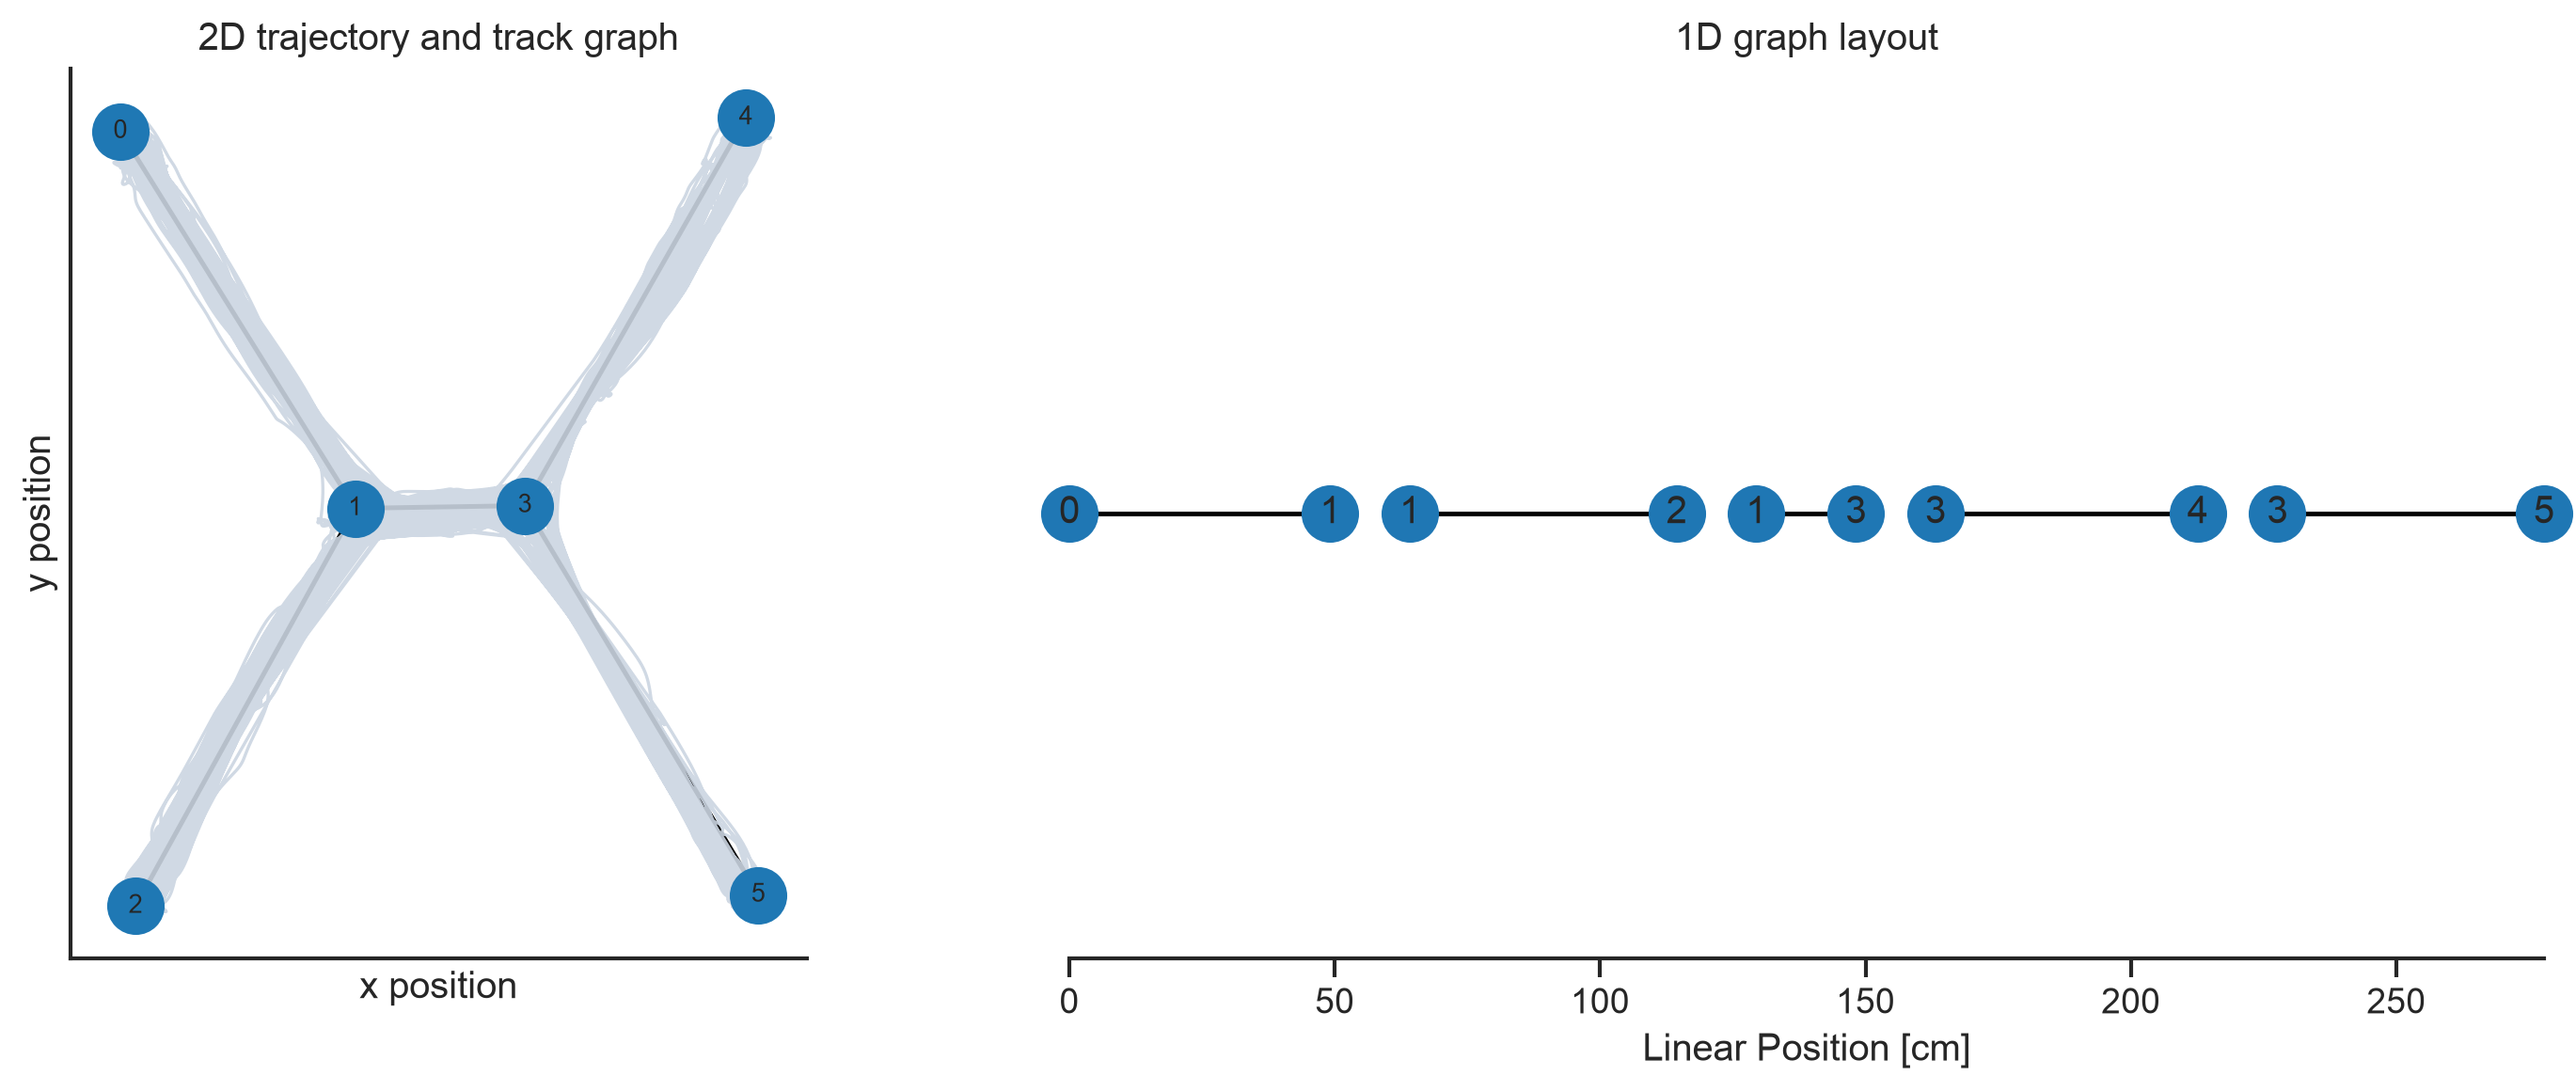

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(position_df['x'], position_df['y'], color=COLORS['gray'], linewidth=1.0, alpha=0.9)
plot_track_graph(track_graph, ax=axes[0])
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_xlabel('x position')
axes[0].set_ylabel('y position')
axes[0].set_title('2D trajectory and track graph')

plot_graph_as_1D(track_graph, edge_spacing=15.0, ax=axes[1])
axes[1].set_title('1D graph layout')

plt.tight_layout()
plt.show()



Then inspect one short time window after linearization.


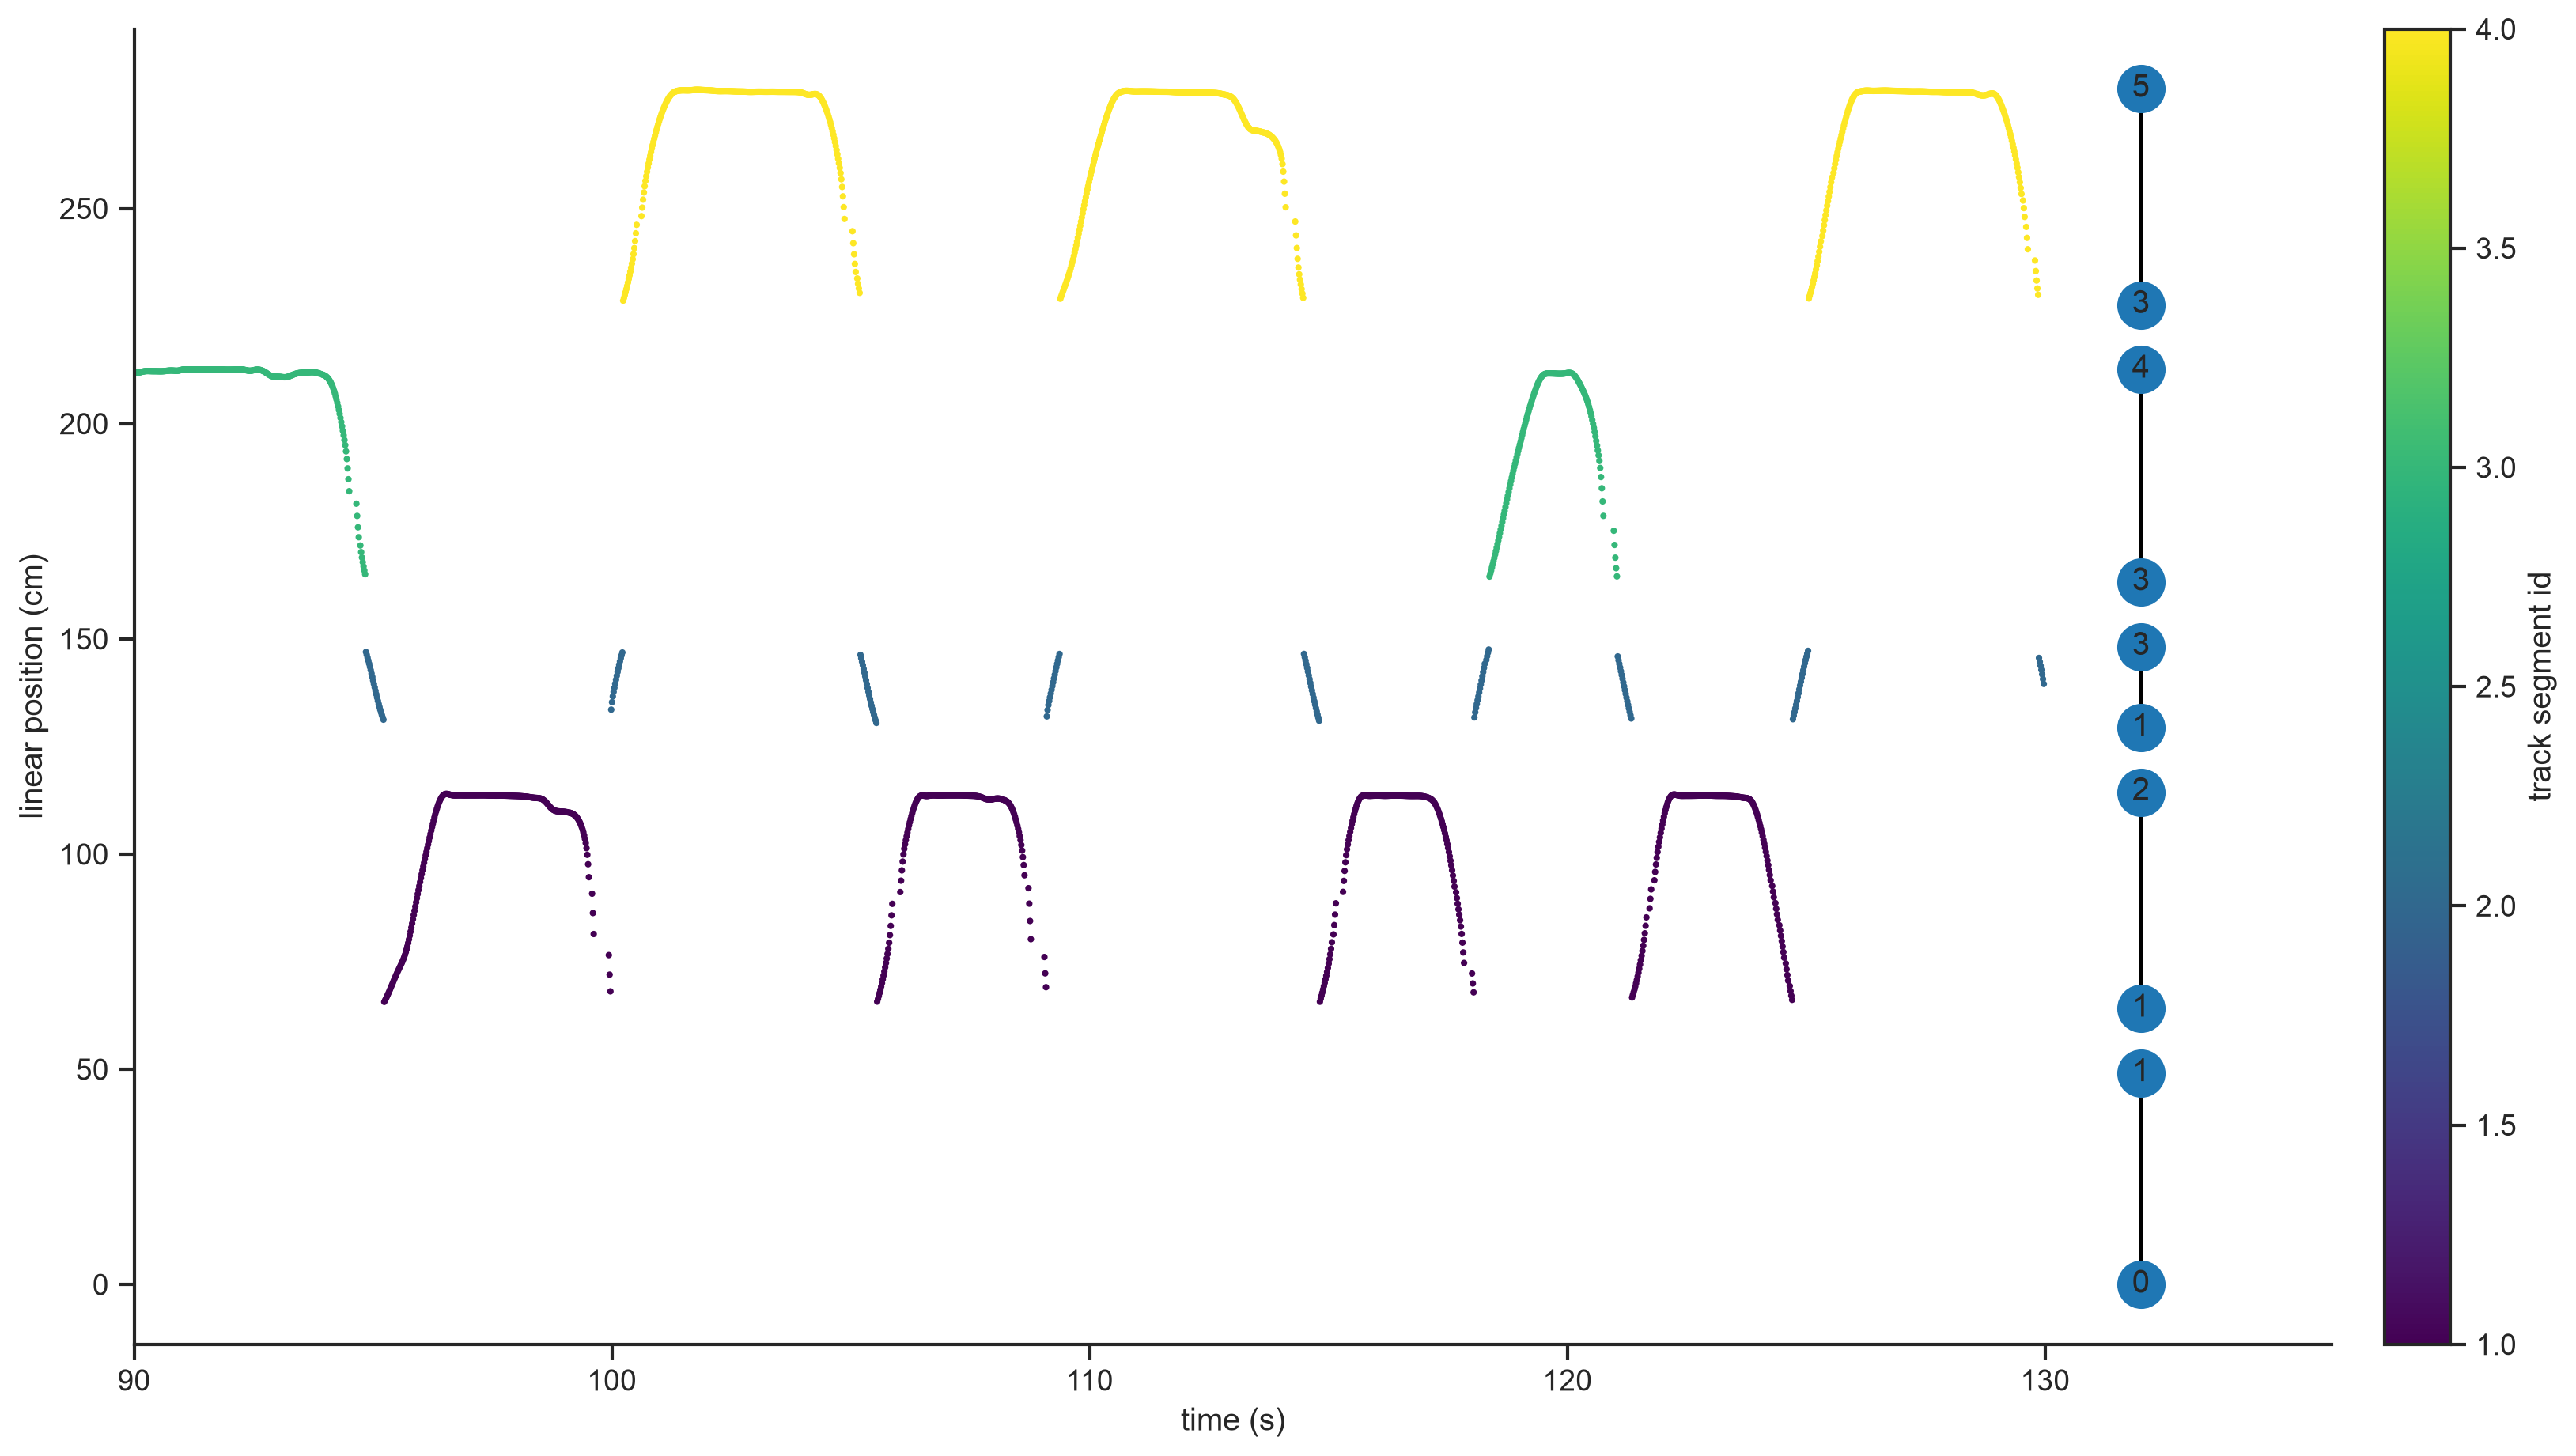

In [41]:
window_start = 90
window_stop = 130

window_df = linear_position_df.query('@window_start <= time <= @window_stop').copy()
if window_df.empty:
    raise ValueError('No samples found in this time window. Choose a different start and stop time.')

fig, ax = plt.subplots(figsize=(18, 9))

scatter = ax.scatter(
    window_df['time'],
    window_df['linear_position'],
    c=window_df['track_segment_id'],
    s=6,
    cmap='viridis',
    linewidths=0,
)

plot_graph_as_1D(
    track_graph,
    edge_spacing=15.0,
    axis='y',
    ax=ax,
    other_axis_start=window_stop + 2.0,
)

plt.colorbar(scatter, ax=ax, pad=0.02, label='track segment id')
ax.set_xlabel('time (s)')
ax.set_ylabel('linear position (cm)')
ax.set_xlim(window_start, window_stop + 6.0)
sns.despine(ax=ax)
plt.show()


## 4. Choose CA1 decoding units

We will decode from CA1. First extract all CA1 units and apply the session-wide mean firing rate filter. Then, after computing linear rate maps, apply the second course filter and keep only units whose smoothed linear rate map peaks above `5 Hz`.


In [42]:
units_table = nwb.units
unit_ids = np.asarray(units_table.id[:])
electrodes_df = nwb.electrodes.to_dataframe()

spike_time_ends = np.asarray(units_table['spike_times_index'].data[:])
total_spikes = np.diff(np.r_[0, spike_time_ends])
session_duration = position_df['time'].iloc[-1] - position_df['time'].iloc[0]
firing_rate_hz = total_spikes / session_duration
regions = [unit_region_from_row(units_table, row_i, electrodes_df) for row_i in range(len(unit_ids))]

units_df = pd.DataFrame({
    'unit_id': unit_ids,
    'region': regions,
    'total_spikes': total_spikes,
    'firing_rate_hz': firing_rate_hz,
}).set_index('unit_id')

ca1_units = units_df[units_df['region'] == 'CA1'].copy().sort_index()
session_max_rate_hz = 5
mean_rate_units = ca1_units[
    ca1_units['firing_rate_hz'] <= session_max_rate_hz
].copy()

print('Region: CA1')
print(f'CA1 units: {len(ca1_units)}')
print(f'Session mean-rate filter: <= {session_max_rate_hz:.1f} Hz')
print(f'Units surviving mean-rate filter: {len(mean_rate_units)} / {len(ca1_units)}')
print('Candidate unit IDs after mean-rate filter:')
print(mean_rate_units.index.to_list())

Region: CA1
CA1 units: 176
Session mean-rate filter: <= 5.0 Hz
Units surviving mean-rate filter: 141 / 176
Candidate unit IDs after mean-rate filter:
[23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 90, 91, 92, 93, 94, 95, 96, 98, 99, 100, 101, 135, 136, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 170, 171, 172, 173, 174, 175, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 205, 206, 207, 301, 302, 304, 305, 306, 310, 311, 312, 313, 315, 316, 321, 322, 325, 327, 332, 334, 336, 337, 338, 339, 340, 341, 342, 346, 347, 348, 349, 352, 364, 365, 366, 367, 368, 369, 370, 371, 372, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 432, 440, 441, 443, 444, 445, 446, 447, 448, 449, 452, 453]


## 5. Creating the encoding model

We build the encoding model as smoothed, occupancy-normalized 1D firing-rate maps along the linearized track. First compute smoothed 2D speed so we can later restrict encoder training to running periods only. Then compute linear occupancy and spike histograms, divide spike counts by occupancy, smooth the rate maps.


In [43]:

time_2d = linear_position_df['time'].to_numpy()
x_2d = linear_position_df['x'].to_numpy()
y_2d = linear_position_df['y'].to_numpy()

dx = np.diff(x_2d)
dy = np.diff(y_2d)
dt_2d = np.diff(time_2d)
distance_cm = np.sqrt(dx**2 + dy**2)
speed_mid = np.full_like(dt_2d, np.nan, dtype=float)
valid_speed = np.isfinite(distance_cm) & np.isfinite(dt_2d) & (dt_2d > 0)
speed_mid[valid_speed] = distance_cm[valid_speed] / dt_2d[valid_speed]

time_mid = time_2d[:-1] + dt_2d / 2
speed_at_position_samples = np.full(len(time_2d), np.nan, dtype=float)
speed_at_position_samples[1:] = speed_mid
smoothed_speed_at_position_samples = hanning_smooth_1d(
    speed_at_position_samples,
    position_smoothing_window_frames,
)

linear_position_df['speed_2d_cm_s'] = smoothed_speed_at_position_samples
decoder_behavior_df['speed_2d_cm_s'] = np.interp(
    decoder_behavior_df['time'].to_numpy(),
    time_2d,
    smoothed_speed_at_position_samples,
)

place_bin_size_cm = 2.5
min_occupancy_s = 0.05
plot_smoothing_sigma = 1

linear_time = linear_position_df['time'].to_numpy()
linear_position = linear_position_df['linear_position'].to_numpy()

dt = np.diff(linear_time)
occupancy_position = linear_position[:-1]
occupancy_valid = np.isfinite(occupancy_position) & np.isfinite(dt)

position_min = np.nanmin(linear_position)
position_max = np.nanmax(linear_position)
linear_edges = np.arange(position_min, position_max + place_bin_size_cm, place_bin_size_cm)
linear_centers = linear_edges[:-1] + place_bin_size_cm / 2

occupancy, _ = np.histogram(
    occupancy_position[occupancy_valid],
    bins=linear_edges,
    weights=dt[occupancy_valid],
)

linear_rate_maps = []
peak_rates = []
peak_positions = []

# Read from mean_rate_units (section 4's output), which already applies the
# session-wide mean-rate filter used to choose decoding units.
for unit_id in mean_rate_units.index:
    spike_times = np.asarray(fetch_unit_spike_times(units_table, unit_ids, unit_id))
    in_range = (spike_times >= linear_time[0]) & (spike_times <= linear_time[-1])
    spike_times = spike_times[in_range]

    spike_positions = map_spikes_to_position_frames(
        spike_times,
        linear_time,
        linear_position,
        np.zeros_like(linear_position),
    )
    spike_linear_position = spike_positions['spike_x']
    spike_counts, _ = np.histogram(spike_linear_position, bins=linear_edges)

    rate_map = np.full_like(linear_centers, np.nan, dtype=float)
    occupied = occupancy > min_occupancy_s
    rate_map[occupied] = spike_counts[occupied] / occupancy[occupied]

    smoothed_rate_map = smooth_linear_rate_map(rate_map, sigma_bins=plot_smoothing_sigma)

    linear_rate_maps.append(smoothed_rate_map)
    if np.all(np.isnan(smoothed_rate_map)):
        peak_rates.append(np.nan)
        peak_positions.append(np.nan)
    else:
        peak_rates.append(np.nanmax(smoothed_rate_map))
        peak_positions.append(linear_centers[np.nanargmax(smoothed_rate_map)])

n_mean_rate_units = len(mean_rate_units)
linear_rate_maps = np.asarray(linear_rate_maps)
peak_rates = np.asarray(peak_rates)
peak_positions = np.asarray(peak_positions)
rate_mapped_units = mean_rate_units.assign(peak_rate_hz=peak_rates)
candidate_units = rate_mapped_units.copy()
sort_order = np.argsort(np.nan_to_num(peak_positions, nan=np.inf))
sorted_unit_ids = candidate_units.index.to_numpy()[sort_order]
sorted_rate_maps = linear_rate_maps[sort_order]

print(f'Finite speed samples: {np.isfinite(speed_mid).sum()} / {len(speed_mid)}')
print(f'Mean 2D speed: {np.nanmean(smoothed_speed_at_position_samples):.2f} cm/s')
print(f'Max 2D speed: {np.nanmax(smoothed_speed_at_position_samples):.2f} cm/s')
print(f'Units entering rate-map step: {n_mean_rate_units}')
print(f'Units retained for decoding: {len(candidate_units)}')
print(f'Linear bins: {len(linear_centers)}')
print(f'Bin size: {place_bin_size_cm} cm')
print(f'Occupied bins: {(occupancy > min_occupancy_s).sum()}')
print(f'Gaussian smoothing sigma: {plot_smoothing_sigma} bins')
print('Final decoding unit IDs after both filters:')
print(candidate_units.index.to_list())

Finite speed samples: 65428 / 65428
Mean 2D speed: 21.47 cm/s
Max 2D speed: 212.68 cm/s
Units entering rate-map step: 141
Units retained for decoding: 141
Linear bins: 112
Bin size: 2.5 cm
Occupied bins: 92
Gaussian smoothing sigma: 1 bins
Final decoding unit IDs after both filters:
[23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 50, 51, 52, 90, 91, 92, 93, 94, 95, 96, 98, 99, 100, 101, 135, 136, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 153, 170, 171, 172, 173, 174, 175, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 205, 206, 207, 301, 302, 304, 305, 306, 310, 311, 312, 313, 315, 316, 321, 322, 325, 327, 332, 334, 336, 337, 338, 339, 340, 341, 342, 346, 347, 348, 349, 352, 364, 365, 366, 367, 368, 369, 370, 371, 372, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 432, 440, 441, 443, 444, 445, 446, 447, 448, 449, 452, 453]


Now let's plot the linear rate map of every selected unit, stacked and sorted by each unit's peak firing position along the track.

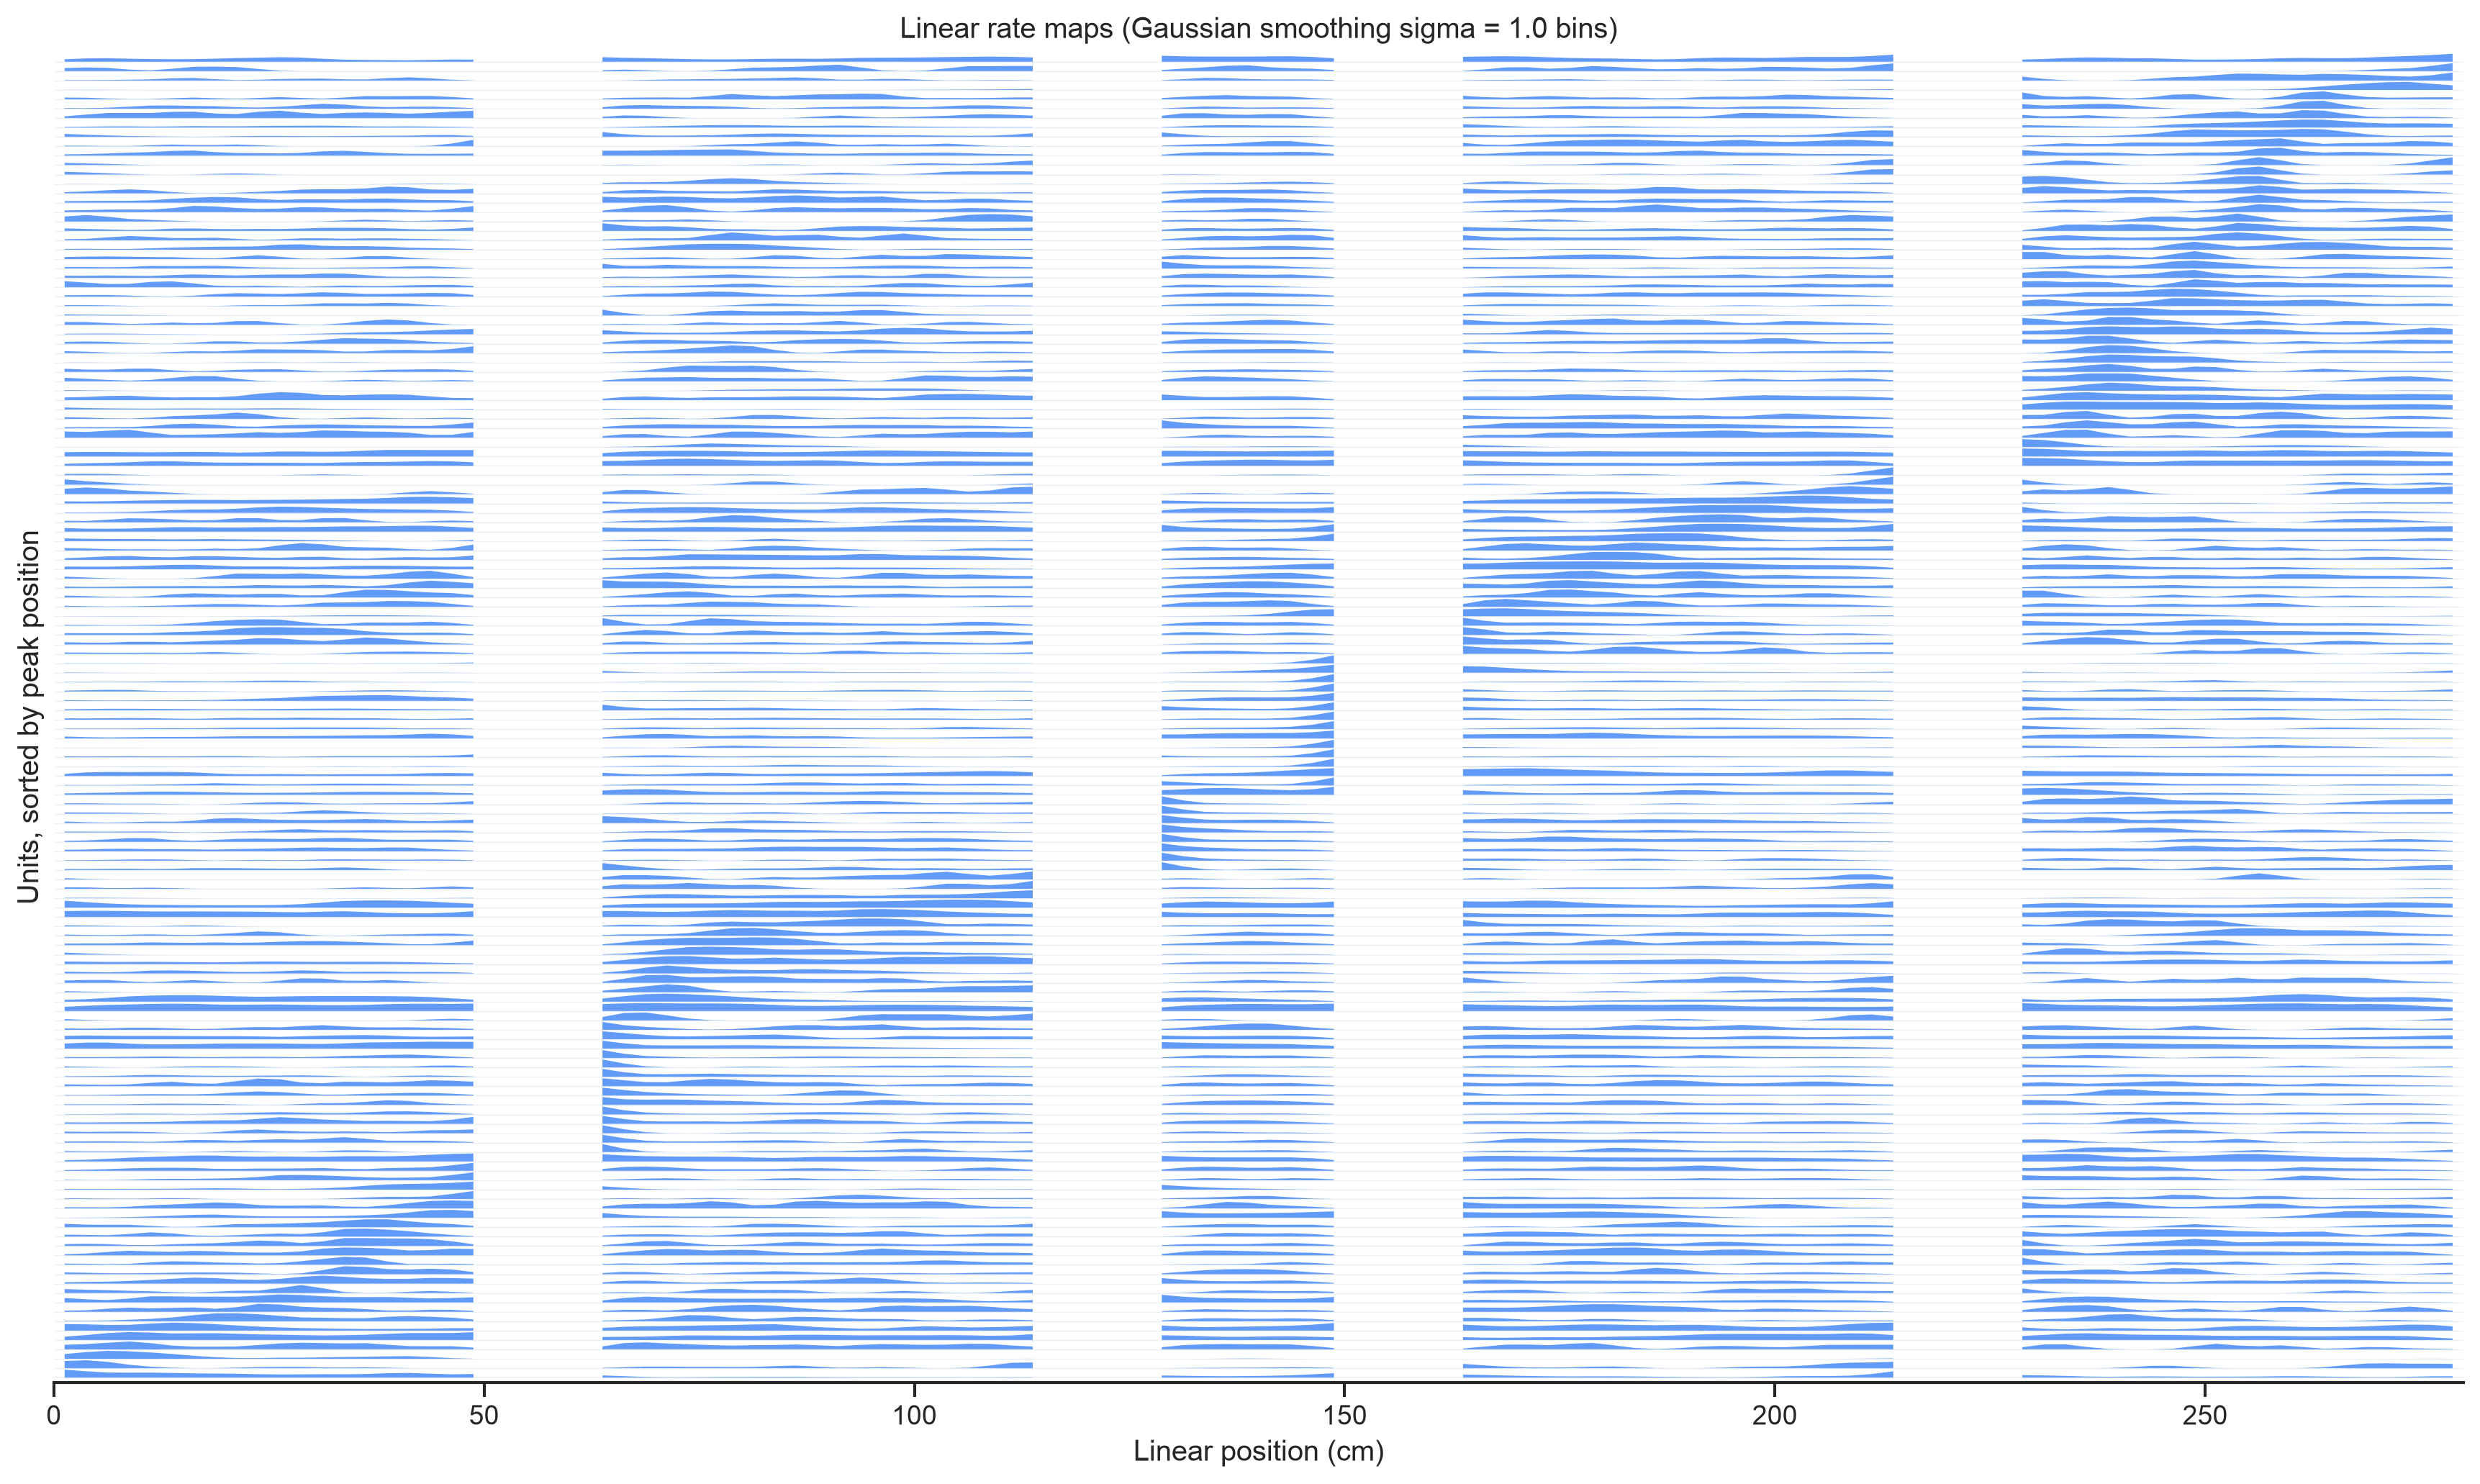

In [33]:
fig_height = max(10, 0.015 * len(sorted_unit_ids))
fig, ax = plt.subplots(figsize=(18, fig_height))

row_step = 1.0
amplitude_scale = 0.85

for row_i, rate_map in enumerate(sorted_rate_maps):
    baseline = row_i * row_step
    ax.hlines(baseline, linear_edges[0], linear_edges[-1], color=COLORS['gray'], linewidth=0.4, alpha=0.35)

    finite = np.isfinite(rate_map)
    if not np.any(finite):
        continue

    map_max = np.nanmax(rate_map)
    if map_max <= 0:
        continue

    scaled_map = baseline + amplitude_scale * (rate_map / map_max)
    ax.fill_between(
        linear_centers,
        baseline,
        scaled_map,
        where=finite,
        color=COLORS['blue'],
        alpha=0.8,
        linewidth=0,
    )

ax.set_xlim(linear_edges[0], linear_edges[-1])
ax.set_ylim(-0.5, len(sorted_unit_ids) * row_step)
ax.set_xlabel('Linear position (cm)')
ax.set_ylabel('Units, sorted by peak position')
ax.set_title(f'Linear rate maps (Gaussian smoothing sigma = {plot_smoothing_sigma:.1f} bins)')
ax.set_yticks([])
sns.despine(ax=ax, left=True)
plt.show()

## 6. Prepare data for decoding

In this section we turn the session into the exact arrays the decoder needs. The big idea is simple: at each moment in time, we want two matched pieces of information:

- what the population of CA1 cells did
- where the animal actually was

To build that dataset, we will bin time, count spikes in each bin, assign one true position to each bin, and then set up train/test splits so that every decoded time bin is evaluated out of sample.


First we choose the decoder time base. Because the behavior table was upsampled to `500 Hz`, each decoding bin is `2 ms` wide. For every bin we then:

- count spikes from every candidate unit
- assign one linearized position from the behavior samples that fall in that bin
- flag bins that cross a track-segment transition

Those transition bins are important: a single 2 ms bin should correspond to one position on one segment. If a bin mixes two segments, it is ambiguous supervision, so we keep track of it and drop it later.


In [ ]:

# Decoder time bin size. Change this here if you want a different decoding time base.
decoder_bin_size_s = 0.002
bin_size_s = decoder_bin_size_s

behavior_df_for_decoding = decoder_behavior_df

session_start = behavior_df_for_decoding['time'].min() - bin_size_s / 2
session_stop = behavior_df_for_decoding['time'].max() + bin_size_s / 2
decode_bin_edges, decode_bin_centers = make_time_bins(session_start, session_stop, bin_size_s)

candidate_unit_ids = candidate_units.index.to_numpy()
spike_count_matrix = bin_spike_counts(units_table, unit_ids, candidate_unit_ids, decode_bin_edges)
(
    binned_linear_position,
    binned_position_sample_count,
    binned_track_segment_id,
    ambiguous_position_bin,
) = bin_linear_position(behavior_df_for_decoding, decode_bin_edges)

decode_df = pd.DataFrame({
    'time': decode_bin_centers,
    'true_linear_position': binned_linear_position,
    'track_segment_id': binned_track_segment_id,
    'n_position_samples': binned_position_sample_count,
    'position_bin_is_ambiguous': ambiguous_position_bin,
})

print(f'Decoding bin width: {bin_size_s:.3f} s')
print(f'Behavior table used for decoding: {len(behavior_df_for_decoding)} samples at {decoder_behavior_sampling_rate_hz:.1f} Hz')
print(f'Number of decoding bins: {len(decode_df)}')
print(f'Spike-count matrix shape: {spike_count_matrix.shape}')
print(f'Ambiguous position bins dropped: {ambiguous_position_bin.sum()}')
display(decode_df.head())


Next we decide how to evaluate the decoder fairly. We use `5` contiguous cross-validation folds, which means the session is cut into long time blocks rather than shuffled individual bins.

That choice matters because nearby time bins are highly correlated. If we shuffled bins at random, the training set and test set would contain nearly identical neighboring moments, and decoding performance would look artificially good. Using contiguous folds makes the test set a much more honest held-out chunk of behavior.

We only split bins that have a valid, unambiguous true position.


In [ ]:
from sklearn.model_selection import KFold

n_splits = 5
valid_position_mask = (
    decode_df['true_linear_position'].notna()
    & ~decode_df['position_bin_is_ambiguous']
)
valid_bin_indices = np.flatnonzero(valid_position_mask.to_numpy())

cv = KFold(n_splits=n_splits, shuffle=False)
folds = list(cv.split(valid_bin_indices))

decode_df['is_valid_for_decoding'] = valid_position_mask

print(f'Cross-validation folds: {n_splits}')
print(f'Valid bins available for decoding: {len(valid_bin_indices)} / {len(decode_df)}')
display(decode_df.loc[valid_position_mask].head(12))


Before decoding, we still need to define the decoder's position grid and a few training rules. This cell does three things:

- defines the segment-aware position bins the decoder is allowed to use
- marks which behavior samples count as running, so the encoder can be trained on movement only
- stores the smoothing, shrinkage, rate-floor, and plotting settings used later in the fold-wise decoder

One important detail is that occupancy is checked separately inside each training fold. So this cell sets the rules, but the final set of usable position bins is determined independently for each fold during decoding.


In [ ]:
position_bin_size_cm = 2
segment_stacked_gap_cm = 12
default_posterior_plot_layout = 'linear'
encoder_movement_speed_threshold_cm_s = 2
min_training_occupancy_s = 0.2
decoder_tuning_smoothing_sigma = 1
decoder_tuning_shrinkage_s = 1.0
decoder_rate_floor_hz = 1e-3

if 'speed_2d_cm_s' not in behavior_df_for_decoding.columns:
    raise ValueError("Run the encoding-model cell first so the movement-only encoder can use speed_2d_cm_s.")

encoder_training_sample_mask = (
    np.isfinite(behavior_df_for_decoding['speed_2d_cm_s'].to_numpy())
    & (behavior_df_for_decoding['speed_2d_cm_s'].to_numpy() > encoder_movement_speed_threshold_cm_s)
)

segment_position_bin_df = build_segment_position_bin_table(
    behavior_df_for_decoding,
    track_graph=track_graph,
    position_bin_size_cm=position_bin_size_cm,
    stacked_gap_cm=segment_stacked_gap_cm,
    edge_spacing_cm=15.0,
).reset_index(drop=True)
decode_df['true_stacked_position'] = map_linear_positions_to_segment_stacked(
    decode_df['true_linear_position'].to_numpy(),
    decode_df['track_segment_id'].to_numpy(),
    segment_position_bin_df,
)

print(f'Position bin size for decoder tuning curves: {position_bin_size_cm:.1f} cm')
print(f'Encoder movement threshold: > {encoder_movement_speed_threshold_cm_s:.1f} cm/s')
print(f'Encoder movement samples kept: {encoder_training_sample_mask.sum()} / {len(encoder_training_sample_mask)}')
print(f'Decoder tuning-curve smoothing sigma: {decoder_tuning_smoothing_sigma:.1f} bins')
print(f'Decoder tuning-curve shrinkage: {decoder_tuning_shrinkage_s:.1f} pseudo-seconds')
print(f'Decoder firing-rate floor: {decoder_rate_floor_hz:.4f} Hz')
print(f'Segment-aware decoding bins: {len(segment_position_bin_df)}')
print(f'Default posterior plot layout: {default_posterior_plot_layout}')
print(f'Position bins with enough training occupancy will be determined separately within each training fold.')


## 7. Decode position from population spikes

Now we use tuning curves learned from fine position samples to predict position in held-out time bins.

Important distinction: the smoothed rate maps and tuning curves above are the encoding model. The decoder below is a Poisson spike-count model that uses those rates as inputs, together with a graph-aware transition prior over position.

For each time bin, we know how many spikes each unit fired. The decoder asks:

- if the animal were at position `x`, how likely would this spike pattern be?
- after combining that likelihood with the graph-based position prior, which positions are most probable?

We first convert each tuning curve into an expected spike count for the current bin width. If unit `i` has tuning curve `f_i(x)` in spikes/s and the decoding bin has width `Δt`, then the expected spike count is:

$$\lambda_i(x) = f_i(x)\Delta t$$

For an observed spike count `n_i`, the Poisson likelihood is:

$$P(n_i\mid x) = \frac{\lambda_i(x)^{n_i}e^{-\lambda_i(x)}}{n_i!}$$

Assuming the units are conditionally independent given position, we combine those likelihoods across units and then apply the graph-aware transition prior to obtain a posterior over position for each time bin.


### 7.1. Set up contiguous cross-validation folds

We now switch from a single train/test split to contiguous cross-validation, like the `pose_analysis` notebook.

We only decode bins that:

- have a valid true linear position
- are not ambiguous across track segments

Then we split those valid bins into `5` contiguous folds.

For each fold:

- train on the other 4 folds
- predict posterior on the held-out fold
- store those held-out predictions

After all folds are done, every valid time bin has a held-out posterior.

In [ ]:
n_decode_bins = len(decode_df)
n_position_bins = len(segment_position_bin_df)

posterior_full = np.full((n_decode_bins, n_position_bins), np.nan, dtype=float)
decoded_linear_position_full = np.full(n_decode_bins, np.nan, dtype=float)
decoded_track_segment_id_full = np.full(n_decode_bins, np.nan, dtype=float)
decoded_stacked_position_full = np.full(n_decode_bins, np.nan, dtype=float)
posterior_mean_position_full = np.full(n_decode_bins, np.nan, dtype=float)
posterior_mean_stacked_position_full = np.full(n_decode_bins, np.nan, dtype=float)
posterior_peak_probability_full = np.full(n_decode_bins, np.nan, dtype=float)
fold_index_full = np.full(n_decode_bins, np.nan, dtype=float)

print(f'Valid bins available for decoding: {len(valid_bin_indices)}')
print(f'Number of folds: {n_splits}')
print(f'Posterior storage shape: {posterior_full.shape}')
display(decode_df.loc[valid_position_mask].head())


### 7.2. Decode one position per bin with a graph-aware posterior

We now run the full cross-validated decoder. The key extra idea is that we do not treat each time bin independently. Instead, after computing the spike-count likelihood, we apply a graph-aware transition prior that favors nearby positions along the maze from one time bin to the next.

In each fold we:

- fit tuning curves using only the training bins
- convert those tuning curves into expected spike counts
- evaluate the held-out spike counts under a Poisson model
- combine that likelihood with the graph-based transition prior
- store the posterior and simple summaries back into the original test bins

The outputs below are therefore held-out decoded positions and posteriors for the whole session.


In [ ]:

transition_sigma_cm = 1
full_graph_transition_matrix = build_graph_position_transition_matrix(
    segment_position_bin_df,
    track_graph=track_graph,
    sigma_cm=transition_sigma_cm,
)

for fold_ind, (train_ind, test_ind) in enumerate(folds, start=1):
    train_bins = valid_bin_indices[train_ind]
    test_bins = valid_bin_indices[test_ind]

    fold_train_mask = np.zeros(len(decode_df), dtype=bool)
    fold_train_mask[train_bins] = True
    fold_training_decode_mask = fold_train_mask & valid_position_mask.to_numpy()

    fold_training_tuning_curves, fold_training_occupancy_s = compute_segment_aware_tuning_curves_from_fine_data(
        units_table=units_table,
        unit_ids=unit_ids,
        candidate_unit_ids=candidate_unit_ids,
        linear_position_df=behavior_df_for_decoding,
        included_decode_bin_mask=fold_training_decode_mask,
        decode_bin_edges=decode_bin_edges,
        position_bin_table=segment_position_bin_df,
        training_sample_mask=encoder_training_sample_mask,
        min_occupancy_s=min_training_occupancy_s,
        smoothing_sigma_bins=decoder_tuning_smoothing_sigma,
        shrinkage_s=decoder_tuning_shrinkage_s,
        rate_floor_hz=decoder_rate_floor_hz,
    )

    fold_position_mask = fold_training_occupancy_s >= min_training_occupancy_s
    fold_candidate_positions = segment_position_bin_df.loc[fold_position_mask, 'linear_position'].to_numpy()
    fold_candidate_stacked_positions = segment_position_bin_df.loc[fold_position_mask, 'stacked_position'].to_numpy()
    fold_candidate_segment_ids = segment_position_bin_df.loc[fold_position_mask, 'segment_id'].to_numpy()
    fold_transition_matrix = subset_transition_matrix(full_graph_transition_matrix, fold_position_mask)
    fold_expected_spike_count_matrix = fold_training_tuning_curves[:, fold_position_mask] * bin_size_s

    fold_test_spike_count_matrix = spike_count_matrix[test_bins]
    fold_log_likelihood = compute_poisson_log_likelihood(
        spike_count_matrix=fold_test_spike_count_matrix,
        expected_spike_count_matrix=fold_expected_spike_count_matrix,
    )
    fold_posterior = apply_position_transition_prior(
        fold_log_likelihood,
        fold_transition_matrix,
    )

    posterior_full[np.ix_(test_bins, fold_position_mask)] = fold_posterior

    fold_decoded_position_index = np.argmax(fold_posterior, axis=1)
    decoded_linear_position_full[test_bins] = fold_candidate_positions[fold_decoded_position_index]
    decoded_track_segment_id_full[test_bins] = fold_candidate_segment_ids[fold_decoded_position_index]
    decoded_stacked_position_full[test_bins] = fold_candidate_stacked_positions[fold_decoded_position_index]
    posterior_mean_position_full[test_bins] = fold_posterior @ fold_candidate_positions
    posterior_mean_stacked_position_full[test_bins] = fold_posterior @ fold_candidate_stacked_positions
    posterior_peak_probability_full[test_bins] = fold_posterior[
        np.arange(len(fold_decoded_position_index)),
        fold_decoded_position_index,
    ]
    fold_index_full[test_bins] = fold_ind

decode_results_df = decode_df.loc[valid_position_mask, ['time', 'true_linear_position', 'track_segment_id', 'true_stacked_position']].copy()
decode_results_df['decoded_linear_position'] = decoded_linear_position_full[valid_position_mask]
decode_results_df['decoded_track_segment_id'] = decoded_track_segment_id_full[valid_position_mask]
decode_results_df['decoded_stacked_position'] = decoded_stacked_position_full[valid_position_mask]
decode_results_df['posterior_mean_position'] = posterior_mean_position_full[valid_position_mask]
decode_results_df['posterior_mean_stacked_position'] = posterior_mean_stacked_position_full[valid_position_mask]
decode_results_df['absolute_error_cm'] = np.abs(
    decode_results_df['decoded_linear_position'] - decode_results_df['true_linear_position']
)
decode_results_df['posterior_mean_absolute_error_cm'] = np.abs(
    decode_results_df['posterior_mean_position'] - decode_results_df['true_linear_position']
)
decode_results_df['posterior_peak_probability'] = posterior_peak_probability_full[valid_position_mask]
decode_results_df['fold_index'] = fold_index_full[valid_position_mask].astype(int)

posterior = posterior_full[valid_position_mask]
decoded_linear_position = decode_results_df['decoded_linear_position'].to_numpy()
decoded_track_segment_id = decode_results_df['decoded_track_segment_id'].to_numpy()
decoded_stacked_position = decode_results_df['decoded_stacked_position'].to_numpy()
posterior_mean_position = decode_results_df['posterior_mean_position'].to_numpy()
posterior_mean_stacked_position = decode_results_df['posterior_mean_stacked_position'].to_numpy()
test_times = decode_results_df['time'].to_numpy()
test_true_positions = decode_results_df['true_linear_position'].to_numpy()
test_true_stacked_positions = decode_results_df['true_stacked_position'].to_numpy()

print(f'Graph-aware transition sigma: {transition_sigma_cm:.1f} cm')
print(f'Cross-validated posterior shape: {posterior.shape}')
print(f'Decoded bins across all folds: {len(decode_results_df)}')
print(f"Median MAP absolute error: {np.median(decode_results_df['absolute_error_cm']):.2f} cm")
print(f"Median posterior-mean absolute error: {np.median(decode_results_df['posterior_mean_absolute_error_cm']):.2f} cm")
display(decode_results_df.head())


### 7.3. Inspect the decoded posterior in a chosen time window

Choose a time window and inspect the graph-aware posterior over position.

- the background image shows posterior probability across position bins
- darker regions mean the decoder assigned higher probability there
- the magenta trace shows the animal's true linear position
- the orange overlay can optionally show the MAP estimate

This lets you see both the decoded summary and the full uncertainty structure of the position-based posterior.


In [ ]:
decode_window_start = 200
decode_window_stop = 400

plot_layout = default_posterior_plot_layout  # Choose 'stacked' or 'linear'.
plot_backend = 'plotly'  # Choose 'plotly' or 'matplotlib'.
decoded_estimate_to_plot = 'none'  # Choose 'map' or 'none'.
plotly_max_time_bins = 100000  # Lower is faster; 1000-3000 is a good interactive range.

window_decode_mask = (test_times >= decode_window_start) & (test_times <= decode_window_stop)
if not np.any(window_decode_mask):
    raise ValueError('No decoded bins found in this time window. Choose a different start and stop time.')

window_times = test_times[window_decode_mask]
window_true_positions = test_true_positions[window_decode_mask]
window_true_stacked_positions = test_true_stacked_positions[window_decode_mask]
window_map_positions = decoded_linear_position[window_decode_mask]
window_map_stacked_positions = decoded_stacked_position[window_decode_mask]
window_posterior_mean_positions = posterior_mean_position[window_decode_mask]
window_posterior_mean_stacked_positions = posterior_mean_stacked_position[window_decode_mask]
window_posterior = posterior[window_decode_mask]

if decoded_estimate_to_plot == 'map':
    window_decoded_positions = window_map_positions
    window_decoded_stacked_positions = window_map_stacked_positions
    decoded_label = 'MAP estimate'
elif decoded_estimate_to_plot == 'none':
    window_decoded_positions = None
    window_decoded_stacked_positions = None
    decoded_label = None
else:
    raise ValueError("decoded_estimate_to_plot must be 'map' or 'none'.")

if plot_layout == 'stacked':
    if plot_backend == 'plotly':
        plot_posterior_segment_stacked_layout_plotly(
            window_times=window_times,
            true_stacked_positions=window_true_stacked_positions,
            decoded_stacked_positions=window_decoded_stacked_positions,
            window_posterior=window_posterior,
            position_bin_table=segment_position_bin_df,
            bin_size_s=bin_size_s,
            decoded_label=decoded_label,
            time_limits=(decode_window_start, decode_window_stop),
            max_plot_time_bins=plotly_max_time_bins,
        )
    elif plot_backend == 'matplotlib':
        plot_posterior_segment_stacked_layout(
            window_times=window_times,
            true_stacked_positions=window_true_stacked_positions,
            decoded_stacked_positions=window_decoded_stacked_positions,
            window_posterior=window_posterior,
            position_bin_table=segment_position_bin_df,
            bin_size_s=bin_size_s,
            decoded_label=decoded_label,
            time_limits=(decode_window_start, decode_window_stop),
        )
    else:
        raise ValueError("plot_backend must be 'plotly' or 'matplotlib'.")
elif plot_layout == 'linear':
    if plot_backend == 'plotly':
        plot_posterior_linear_layout_plotly(
            window_times=window_times,
            true_linear_positions=window_true_positions,
            decoded_linear_positions=window_decoded_positions,
            window_posterior=window_posterior,
            position_bin_table=segment_position_bin_df,
            bin_size_s=bin_size_s,
            decoded_label=decoded_label,
            time_limits=(decode_window_start, decode_window_stop),
            max_plot_time_bins=plotly_max_time_bins,
        )
    elif plot_backend == 'matplotlib':
        plot_posterior_linear_layout(
            window_times=window_times,
            true_linear_positions=window_true_positions,
            decoded_linear_positions=window_decoded_positions,
            window_posterior=window_posterior,
            position_bin_table=segment_position_bin_df,
            bin_size_s=bin_size_s,
            decoded_label=decoded_label,
            time_limits=(decode_window_start, decode_window_stop),
        )
    else:
        raise ValueError("plot_backend must be 'plotly' or 'matplotlib'.")
else:
    raise ValueError("plot_layout must be 'stacked' or 'linear'.")
